In [1]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [2]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4.1-nano"
db_name = "vector_db"
load_dotenv(override=True)
openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

OpenAI API Key exists and begins sk-proj-


In [3]:
# Load in everything in the knowledgebase using LangChain's loaders

folders = glob.glob("../KnowledgeBase/*")

documents = []
for folder in folders:
    try:
        doc_type = os.path.basename(folder)
        loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs={'encoding': 'utf-8'})
        folder_docs = loader.load()
        for doc in folder_docs:
            doc.metadata["doc_type"] = doc_type
            documents.append(doc)
    except Exception as e:
        print(f"{folder} is not a folder: {e}")
print(f"Loaded {len(documents)} documents")

Loaded 110 documents


In [4]:
documents[1]

Document(metadata={'source': '..\\KnowledgeBase\\Customer_Support\\HH-11_INSTALL_SMARTLOCK.md', 'doc_type': 'Customer_Support'}, page_content='---\ndoc_id: HH-11\ntitle: Installation Guide — SecureNest SN-L2 Smart Lock\ndoc_type: installation_guide\nversion: 1.3\nlast_updated: 2026-01-19\n---\n\n# SecureNest SN-L2 — Installation Guide (Compatibility + Setup)\n\n## A) Door compatibility requirements (important)\n- Door thickness: **35–55 mm**\n- Backset: **60 mm or 70 mm**\n- Existing deadbolt hole: **54 mm** diameter (common standard)\n- Edge bore: **25 mm** diameter\n- Works best with a single-cylinder deadbolt door prep\n\nIf your door does not match these measurements, installation may require additional drilling.\n\n## B) HomeHaven installation add-on\n**Fee:** AED 99  \nIncludes:\n- Removing existing lock (if compatible)\n- Fitting SN-L2 exterior and interior units\n- Deadbolt alignment check\n- Basic app pairing (Bluetooth) and PIN setup\n\nNot included:\n- Painting/repairing doo

In [5]:
# Divide into chunks using the RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"First chunk:\n\n{chunks[0]}")

Divided into 334 chunks
First chunk:

page_content='---
doc_id: HH-10
title: Installation Guide — AquaClean DW60 Built-in Dishwasher
doc_type: installation_guide
version: 1.2
last_updated: 2026-01-19
---

# AquaClean DW60 Built-in Dishwasher — Installation Guide (Customer Prep + Technician Steps)

## A) Before you book installation (customer checklist)
You should have:
1. **Space:** 60cm cabinet opening (standard built-in size)
2. **Power:** grounded outlet within reach (no loose adapters)
3. **Water inlet:** accessible shut-off valve
4. **Drain:** connection point ready (sink trap or dedicated drain)
5. **Pathway:** clear access from door to installation area

If any of the above are missing, installation may be postponed and a revisit fee may apply.

## B) HomeHaven standard installation (service scope)
**Fee:** AED 149  
Includes:
- Unboxing and visual inspection
- Positioning and leveling
- Connecting inlet hose and drain hose to existing points
- Basic function test (power on, fil

In [6]:
chunks[100]

Document(metadata={'source': '..\\KnowledgeBase\\Internal_Ops\\HH-68_RETURNS_INSTORE_PROCESSING_GUIDE.md', 'doc_type': 'Internal_Ops'}, page_content='## In-Store Documentation\n- Maintain a dedicated returns folder for each location with templates for: receipt, serial capture, photos, and notes.\n- Use the same photos and notes demanded for courier-based damage claims (HH-21).\n\n## Customer Communication\n- Confirm the item’s condition and reason for return.\n- Explain estimated processing time for refunds (5–12 business days for card; faster for store credits depending on payment method).\n\n## Exceptions\n- Opened consumables are generally restricted (HH-04) unless defective.\n- Bundled items may require returning the entire bundle (HH-43).\n\n## Security & Fraud\n- Verify customer identity if needed by policy; avoid processing refunds to third parties.\n\n## KPIs\n- In-store return processing time (target ≤ 6–8 minutes per item)\n- Return accuracy rate (target ≥ 98%)')

In [7]:
chunks[99]

Document(metadata={'source': '..\\KnowledgeBase\\Internal_Ops\\HH-68_RETURNS_INSTORE_PROCESSING_GUIDE.md', 'doc_type': 'Internal_Ops'}, page_content='---\ndoc_id: HH-68\ntitle: Returns — In-Store Processing Guide\ndoc_type: guideline\nversion: 1.0\nlast_updated: 2026-01-26\n---\n\n## Objective\nProvide a clear, fast, and customer-friendly in-store returns process that aligns with online policies (HH-04) while ensuring proper inspection and restocking practices.\n\n## Workflow\n1) Customer presents item with packaging and receipt.\n2) Scan order to verify eligibility (within 30 days; items unused; original packaging present).\n3) Inspect item for wear, missing parts, and serial number match (per HH-04 and HH-22).\n4) Determine refund type (card refund, store credit, or exchange) based on policy and product category.\n5) Process return through POS system; issue receipt or store credit; update inventory accordingly.\n6) If item is defective, initiate warranty flow (HH-05) where applicable

In [8]:
# Pick an embedding model

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorstore created with 334 documents


In [9]:
# Let's investigate the vectors

collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

There are 334 vectors with 384 dimensions in the vector store


In [10]:
# Prework

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['doc_type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange', 'purple', 'brown'][['Customer_Support', 'Internal_Ops', 'Policies_Legal', 'product_catalog','Programs_Services','Reference_Tech'].index(t)] for t in doc_types]

In [11]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=19)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

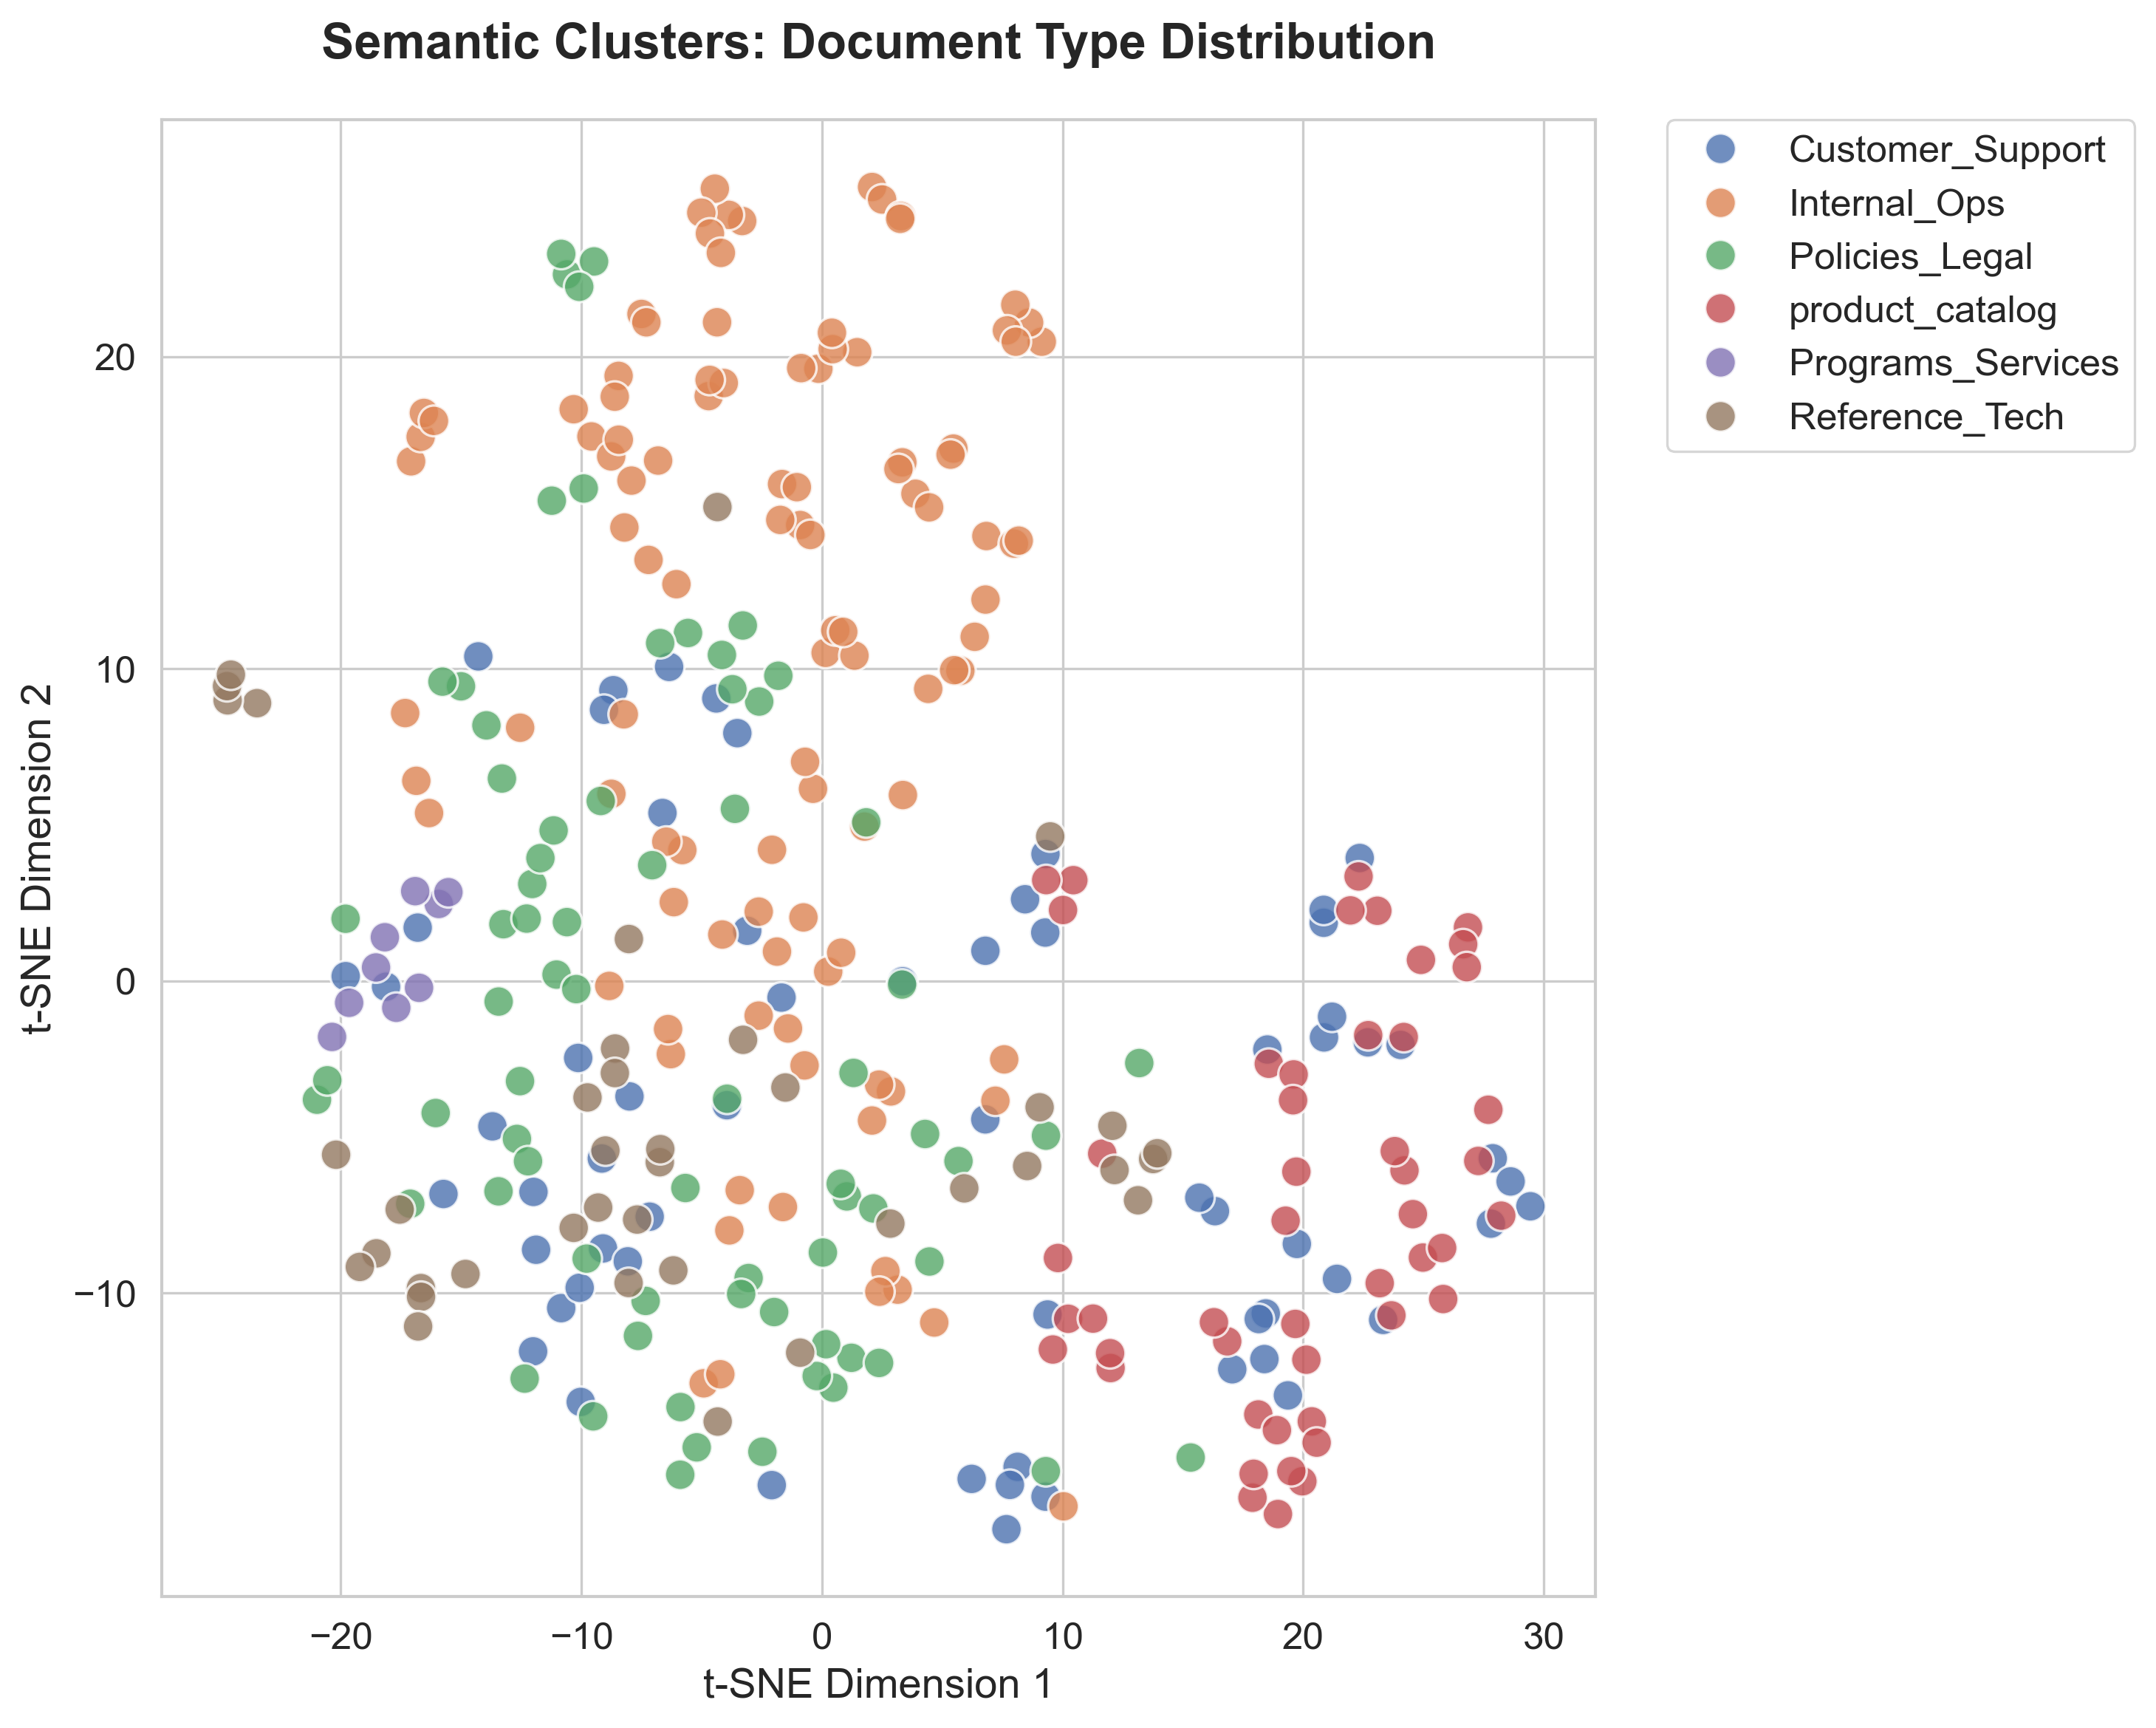

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare Data (Same as Altair)
df = pd.DataFrame({
    'x': reduced_vectors[:, 0],
    'y': reduced_vectors[:, 1],
    'Category': doc_types  # Seaborn uses this for the Legend automatically
})

# 2. Set Style (Optional but recommended for reports)
# 'whitegrid' is clean; 'ticks' is good for academic papers.
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4) # Boost font size for readability

# 3. Create the Plot
plt.figure(figsize=(10, 8), dpi=300) # High resolution setup
scatter = sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue='Category',      # Color by category
    palette='deep',      # Professional colorblind-friendly palette
    s=100,               # Marker size
    alpha=0.8,           # Transparency
    edgecolor='w'        # White border around dots for contrast
)

# 4. Polish Labels
plt.title('Semantic Clusters: Document Type Distribution', fontsize=16, weight='bold', pad=20)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0) # Move legend outside

# 5. Save for Report
plt.tight_layout() # Fix margins automatically
plt.savefig('vector_clusters_report.png', dpi=300, bbox_inches='tight')
plt.savefig('vector_clusters_report.pdf', bbox_inches='tight') # Best for LaTeX/PDF reports
plt.show()


In [13]:
import pandas as pd
import altair as alt

# 1. Structure Data into a DataFrame
# Altair requires a clean tabular format to map columns to visual properties.
df = pd.DataFrame({
    'x': reduced_vectors[:, 0],
    'y': reduced_vectors[:, 1],
    'doc_type': doc_types,
    'snippet': [doc[:100] + "..." for doc in documents]  # Truncate for cleaner tooltips
})

# 2. Define the Chart
# We map 'doc_type' to color automatically - no need to manually define hex codes.
chart = alt.Chart(df).mark_circle(size=60, opacity=0.8).encode(
    x=alt.X('x', title='Dimension 1'),
    y=alt.Y('y', title='Dimension 2'),
    
    # Semantic Mapping
    color=alt.Color('doc_type', legend=alt.Legend(title="Document Type")),
    
    # Interactive Tooltips
    tooltip=[
        alt.Tooltip('doc_type', title='Category'),
        alt.Tooltip('snippet', title='Text Preview')
    ]
).properties(
    title='2D Chroma Vector Store Visualization',
    width=800,
    height=600
).interactive()  # Enables Zoom/Pan

# 3. Render
chart.show()
# Or save to HTML for your report:
# chart.save('vector_clusters.html')

alt.Chart(...)

In [14]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()